# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [Evaluation & Save Utilities](#evaluation--save-utilities)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
    - [Hexagon Encoding](#hexagon-encoding)
- [Feature Selection](#feature-selection)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [Embed Dimension Search](#embed-dimension-search)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Tuned Deeper — Training](#4212-tuned-deeper--training)
  - [4.2.12 Tuned Deeper — Evaluation](#4212-tuned-deeper--evaluation)
- [4.2.13 Wider Model — Training](#4213-wider-model--training)
  - [4.2.13 Wider Model — Evaluation](#4213-wider-model--evaluation)
- [4.2.14 Hyperparameter Search — Wider Model](#4214-hyperparameter-search--wider-model)
  - [4.2.14 Tuned Wider — Training](#4214-tuned-wider--training)
  - [4.2.14 Tuned Wider — Evaluation](#4214-tuned-wider--evaluation)
- [4.2.15 Visualization: Architecture Comparison](#4215-visualization-architecture-comparison)
  - [Learning Curves](#learning-curves)
  - [Statistical Significance — Wilcoxon Signed-Rank](#statistical-significance--wilcoxon-signed-rank)
    - [Interpreting the results](#interpreting-the-results)


In [43]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [44]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [45]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/hexagon/demand_hex_6h_low.parquet")

In [46]:
data

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,862664197ffffff,residential,1,1,15.000000,818.000000,14.540000,35.750000,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.000000,0.000000,0.027498,0.659954
1,2025-01-01 00:00:00,482136,86266419fffffff,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.000000,0.000000,0.027521,0.330253
2,2025-01-01 00:00:00,482136,8626641b7ffffff,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.000000,0.000000,0.000000,0.302173
3,2025-01-01 00:00:00,482136,862664527ffffff,airport,5,5,0.000000,1676.000000,12.868000,33.700000,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.000000,0.000000,0.000000,0.961182
4,2025-01-01 00:00:00,482136,86266452fffffff,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.054970,0.027485,0.027485,1.346772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48175,2025-12-31 18:00:00,490890,862664dafffffff,residential,2,2,30.000000,1146.000000,4.780000,15.565000,...,3.960234,4.291273,0.000000,0.027329,0.000000,0.000000,0.000000,0.000000,0.000000,0.027329
48176,2025-12-31 18:00:00,490890,862759347ffffff,airport,199,186,131.351351,2061.010050,14.953568,39.344925,...,2.892475,2.057285,0.136860,1.176998,0.301092,0.520069,0.000000,0.000000,0.027372,2.162392
48177,2025-12-31 18:00:00,490890,86275934fffffff,airport,219,191,129.179104,1946.347032,14.084886,37.325342,...,1.220338,2.809967,0.191761,1.068385,0.465706,0.383523,0.000000,0.000000,0.027394,2.136770
48178,2025-12-31 18:00:00,490890,86275935fffffff,airport,67,67,145.125000,2002.208955,14.049701,36.960896,...,1.340206,7.539746,0.054799,0.273996,0.054799,0.027400,0.000000,0.000000,0.000000,0.410994


## 4.2.1 Data Information

In [47]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each hexagon + hour-of-day combination appear?
hex_hour_counts = data.groupby(['pickup_h3_res6', 'hour_of_day']).size()

print(f"\n--- Hexagon × Hour-of-day ---")
print(f"Unique hex × hour combinations : {len(hex_hour_counts):>8,}")
print(f"Avg appearances per combo      : {hex_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {hex_hour_counts.min():>8,}")
print(f"Max appearances                : {hex_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     48,180
Unique combinations (no time) :     48,180
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   48,180 combinations

--- Hexagon × Hour-of-day ---
Unique hex × hour combinations :      132
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :    6,956  (14.4%)
Non-zero-demand rows           :   41,224  (85.6%)


In [48]:
data.head()

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,1,1,15.0,818.0,14.540,35.75,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.00000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,0,0,0.0,0.0,0.000,0.00,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.00000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,0,0,0.0,0.0,0.000,0.00,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.00000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,5,5,0.0,1676.0,12.868,33.70,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.00000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,0,0,0.0,0.0,0.000,0.00,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.05497,0.027485,0.027485,1.346772


## 4.2.2 Model Configurations

In [88]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-6
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 300

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- hex embedding ---
HEX_EMBED_DIM      = 16      # learned embedding dim per hexagon

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    HEX_EMBED_DIM  = HEX_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-7, 5e-7, 8e-7, 2e-6, 5e-6, 8e-6, 2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))           # step 2: multipliers inside the winning decade


## 4.2.3 Model Definition

In [50]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_hex, embed_dim):
        super().__init__()
        self.hex_embed = nn.Embedding(n_hex, embed_dim)
        nn.init.normal_(self.hex_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, hex_idx):
        emb = self.hex_embed(hex_idx)          # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)      # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _embed_dim  = embed_dim  if embed_dim  is not None else config.HEX_EMBED_DIM
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_HEX, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train,   dtype=torch.float32),
            torch.as_tensor(hex_train, dtype=torch.long),
            torch.as_tensor(y_train,   dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t   = torch.as_tensor(X_val,   dtype=torch.float32).to(device)
    hex_val_t = torch.as_tensor(hex_val, dtype=torch.long).to(device)
    y_val_t   = torch.as_tensor(y_val,   dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, hb, yb in train_dl:
            xb, hb, yb = xb.to(device), hb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, hb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, hex_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [51]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  hex_train, hex_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model per seed in HP_SEARCH_SEEDS and is
    scored by the mean validation loss, so the search is reproducible.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        hex_train, hex_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades. Both steps are exhaustive grids, so
    only rough orders of magnitude need to be known upfront."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           hex_train, hex_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         hex_train, hex_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers used after every training run below: `evaluate_models` computes the test-set metrics for the per-seed models of one architecture and returns the result rows, `save_results` appends them to the results CSV.

In [52]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, hex_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check (MSE, log1p scale) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [53]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌─────────────────┬──────────────────────────────┬─────────────┐
│ pickup_h3_res6  │  is_weekend, temp, rain, ...  │ trip_count  │
│ '862664197ffffff' │  0,  12.3,  0.0,  ...      │      5      │
└────────┬────────┴───────────────┬───────────────┴──────┬──────┘
         │                       │                       │
         ▼                       ▼                       ▼
    hex_vocab              StandardScaler             target y
  '862664197ffffff'       [0.0, -0.3, ...]              5.0
       → 42
         │                       │
         ▼                       │
  Embedding table                │
  (N_HEX hexagons × 16 dims)     │
  row 42: [0.12, -0.31, ...]     │
     (16 dims, learned)          │ (n_num dims, scaled)
         │                       │
         └───────────┬───────────┘
                     ▼
               torch.cat(...)
          [0.12, -0.31, ..., 0.0, -0.3, ...]
              (16 + n_num total dims)
                     │
                     ▼
           ┌─────────────────────┐
           │  Linear(dim → 64)   │
           │  ReLU               │
           │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
           │  ReLU               │
           │  Linear(64 → 1)     │
           │  Softplus           │  ← keeps output ≥ 0 (trip count)
           └─────────────────────┘
                     │
                     ▼
              ŷ  (predicted trip count)
```

The embedding table starts with near-zero weights and is updated by backprop
alongside all other parameters — the network learns which hexagons are similar.


## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [54]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    33,726 rows
Val   :     7,227 rows
Test  :     7,227 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Hexagon Encoding

Hexagon identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network. With far more hexagons than the ~77 community
areas, one-hot encoding would blow up the input dimension and give rarely-seen
hexagons poorly estimated independent weights; a compact embedding shares
statistical strength across hexagons instead.

The vocabulary is built on the **training set only**. Hexagons that appear only
in val/test map to a reserved "unknown" index so the model degrades gracefully
instead of failing on unseen locations.


In [55]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    # "bars_and_pubs_per_km2", "train_station_per_km2",
    # "attractions_per_km2", "hospitals_per_km2",
    # "area_km2", "dist_to_nearest_stadium_km", "percipitation"
    # "temperature_2m", "rain", "wind_speed_10m",
    # "poi_density_total_per_km2",
    # "universities_per_km2",
    # "cloud_cover",
    # "is_day", 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover',
    # "snowfall"
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (29): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'is_day', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'universities_per_km2', 'attractions_per_km2', 'poi_density_total_per_km2']
Target scale : raw counts (count NLL)
Unique hexagons (train) : 33  |  embed dim : 16
Unseen hexes  val: 0   test: 0

X_train : (33726, 29)   y_train : (33726,)
X_val   : (7227, 29)     y_val   : (7227,)
X_test  : (7227, 29)    y_test  : (7227,)


## Feature Selection

We select our features as described in the following:

1. correlation matrix
2. model-based feature importance

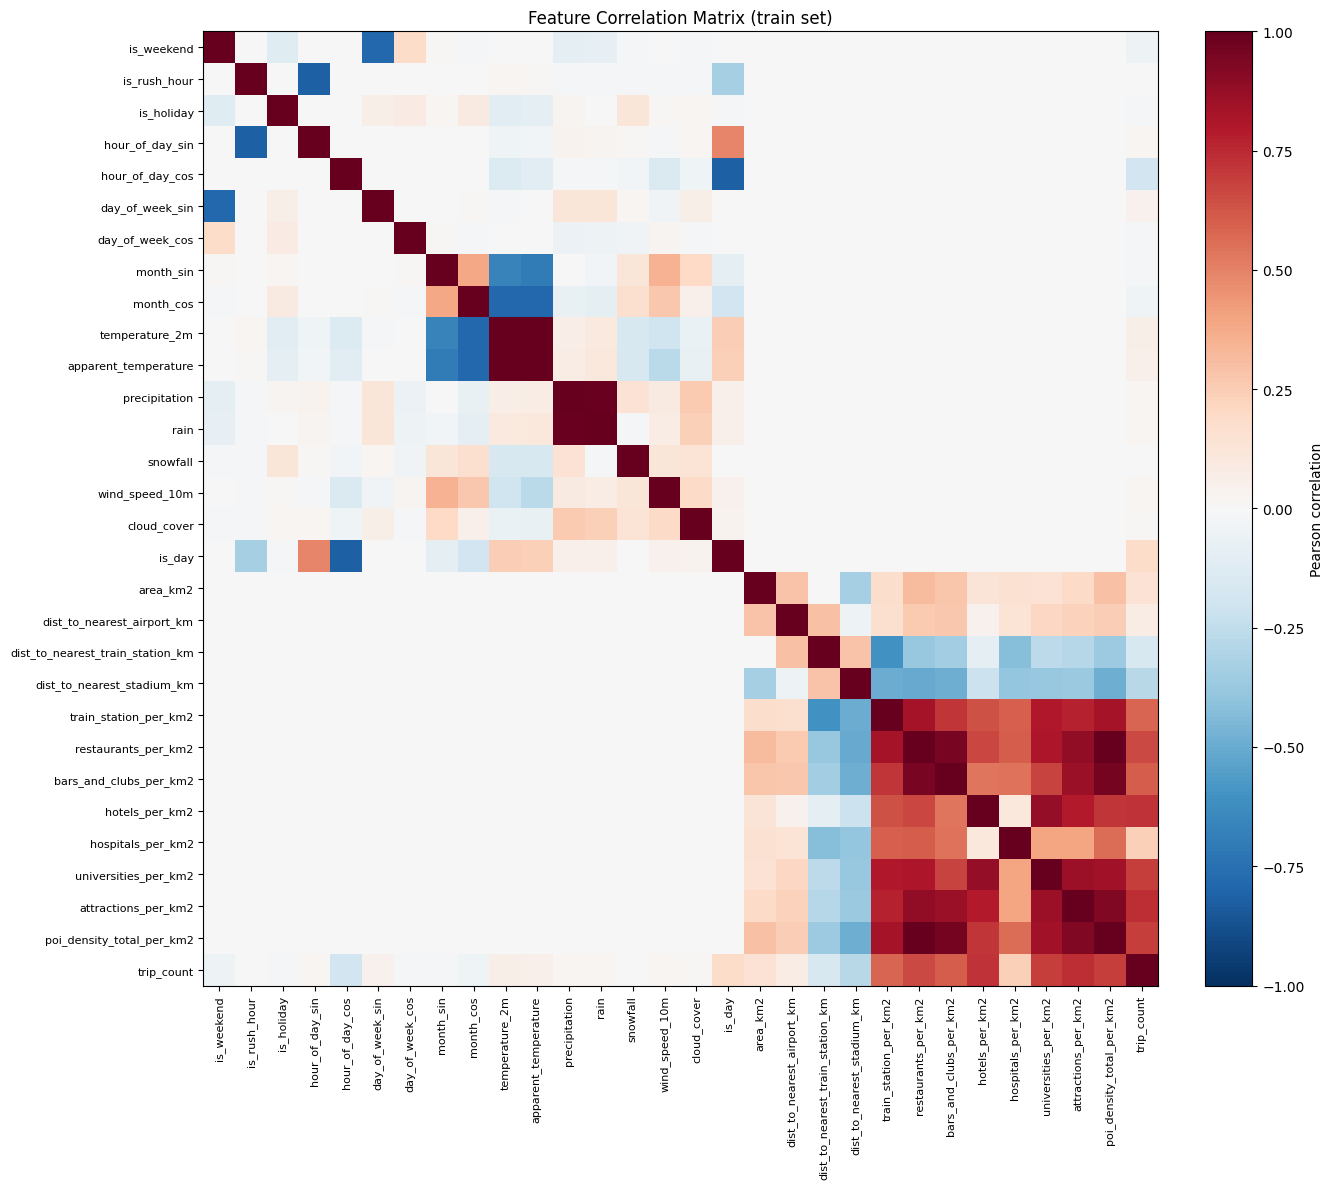

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs poi_density_total_per_km2            r=+0.995
  temperature_2m                      vs apparent_temperature                 r=+0.995
  precipitation                       vs rain                                 r=+0.986
  bars_and_clubs_per_km2              vs poi_density_total_per_km2            r=+0.956
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.952
  attractions_per_km2                 vs poi_density_total_per_km2            r=+0.924
  restaurants_per_km2                 vs attractions_per_km2                  r=+0.888
  hotels_per_km2                      vs universities_per_km2                 r=+0.875
  bars_and_clubs_per_km2              vs attractions_per_km2                  r=+0.863
  universities_per_km2                vs attractions_per_km2                  r=+0.855
  universities_per_km2                vs poi_density_total_per_km2            r=+0.837
  

In [56]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [57]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                          is_day       0.167433         0.267109             0.005872
                 hour_of_day_cos       0.086828         0.138805             0.002346
       poi_density_total_per_km2       0.123946         0.088392             0.001409
           train_station_per_km2       0.099392         0.078640             0.001212
             attractions_per_km2       0.105806         0.067082             0.001110
      dist_to_nearest_airport_km       0.024177         0.056008             0.000740
                 day_of_week_sin       0.025523         0.041216             0.001368
             restaurants_per_km2       0.076037         0.037922             0.000634
          bars_and_clubs_per_km2       0.050068         0.035541             0.000358
                  hotels_per_km2       0.080147         0.028938             0.000631
            universities_per_km2       0.074461       

In [58]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Selection.                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    "bars_and_pubs_per_km2", "train_station_per_km2",
    # "attractions_per_km2", "hospitals_per_km2",
    # "area_km2", "dist_to_nearest_stadium_km", "percipitation"
    "temperature_2m", "rain", "wind_speed_10m",
    "poi_density_total_per_km2",
    "universities_per_km2",
    # "cloud_cover",
    "is_day", 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover',
    # "snowfall"
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (18): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : raw counts (count NLL)
Unique hexagons (train) : 33  |  embed dim : 16
Unseen hexes  val: 0   test: 0

X_train : (33726, 18)   y_train : (33726,)
X_val   : (7227, 18)     y_val   : (7227,)
X_test  : (7227, 18)    y_test  : (7227,)


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [59]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_h3_res6', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_h3_res6', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_h3_res6', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (hex × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146

Historical mean (hex × hour)         R²=0.8584  MAE=38.8114  RMSE=120.1507  NRMSE=1.1398  MAPE=80.8%
Ridge regression                     R²=0.6509  MAE=71.2392  RMSE=188.6138  NRMSE=1.7893  MAPE=374.4%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner globally for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (1 seed, early stopping).


In [60]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
HEX_EMBED_DIM        = best_embed_dim
config.HEX_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {HEX_EMBED_DIM}  →  set as global HEX_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=5

  embed_dim=  8  val_loss=4.3585
  embed_dim= 16  val_loss=4.3169
  embed_dim= 32  val_loss=4.1560

Best embed_dim: 32  →  set as global HEX_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [61]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_HEX, HEX_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
h_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, h_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 18]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   1,088
├─Sequential: 1-2                        [1, 50]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 50]                   [1, 64]                   3,264
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 8,578
Trainable params: 8,578
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 18]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   1,088
├─Sequential: 1-2                        [1, 50]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 50]                   [1, 64]                   3,264
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 8,578
Trainable params: 8,578
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

In [62]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/300
  loss: 26.2962  val_loss: 5.5804 ✓
Epoch   2/300
  loss: 5.7094  val_loss: 5.4267 ✓
Epoch   3/300
  loss: 5.5833  val_loss: 5.3446 ✓
Epoch   4/300
  loss: 5.4937  val_loss: 5.2756 ✓
Epoch   5/300
  loss: 5.4181  val_loss: 5.2159 ✓
Epoch   6/300
  loss: 5.3526  val_loss: 5.1627 ✓
Epoch   7/300
  loss: 5.2946  val_loss: 5.1152 ✓
Epoch   8/300
  loss: 5.2429  val_loss: 5.0725 ✓
Epoch   9/300
  loss: 5.1967  val_loss: 5.0339 ✓
Epoch  10/300
  loss: 5.1544  val_loss: 4.9987 ✓
Epoch  11/300
  loss: 5.1167  val_loss: 4.9668 ✓
Epoch  12/300
  loss: 5.0820  val_loss: 4.9374 ✓
Epoch  13/300
  loss: 5.0503  val_loss: 4.9107 ✓
Epoch  14/300
  loss: 5.0213  val_loss: 4.8862 ✓
Epoch  15/300
  loss: 4.9944  val_loss: 4.8635 ✓
Epoch  16/300
  loss: 4.9699  val_loss: 4.8427 ✓
Epoch  17/300
  loss: 4.9469  val_loss: 4.8234 ✓
Epoch  18/300
  loss: 4.9257  val_loss: 4.8058 ✓
Epoch  19/300
  loss: 4.9064  val_loss: 4.7891 ✓
Epoch  20/300
  loss: 4.8879  val_loss: 4.7737 ✓
Epoch 

### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [63]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, hex_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0 layer weight stats:
    hex_embed.weight  shape=(34, 32)      max|w|=0.1147  mean|w|=0.0166  norm=0.7597
    net.0.weight    shape=(64, 50)      max|w|=0.6823  mean|w|=0.1622  norm=11.4774
    net.2.weight    shape=(64, 64)      max|w|=0.6800  mean|w|=0.1417  norm=11.3867
    net.4.weight    shape=(1, 64)       max|w|=0.5690  mean|w|=0.1613  norm=1.6168
  seed=0  R²=0.6872  MAE=54.5644  NRMSE=1.6938  MAPE=137.3%  | zeros 24/1,215  false=3  | pred min=0.3 max=1841.8

--- original scale ---
Baseline  R²    : 0.6872 ± 0.0000
Baseline  MAE   : 54.5644 ± 0.0000
Baseline  RMSE  : 178.5560 ± 0.0000
Baseline  NRMSE : 1.6938 ± 0.0000
Baseline  MAPE  : 137.31% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 24.0 ± 0.0  (out of 1,215)
Baseline  False-zero   : 3.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred mi

In [64]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (29 columns)
          timestamp training_loss    model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation  d2  poisson_deviance       mape
2026-07-20T20:10:08        nb_nll baseline         2     64        0.00005           0.0        1024     0  4.155975               1215   105.414557 0.687168 54.564431 178.556039 1.693846 0.658724 0.841831   1.15275   0.434369            24           3  0.325058 1841.804932                   NaN              relu NaN               NaN 137.312523


## 4.2.10 Hyperparameter Search — Baseline Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-5 → 1e-5, 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 8e-5, 9e-5), evaluated only inside the decades that
   won step 1.

The broad ranges of decades were chosen by trial and error. Therefore, different notebooks can have different HP_LR_DECADES candidates.

In [91]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-05    5.00e-04      4.3169  complete
   2    5.00e-07    0.00e+00      5.3775  complete
   3    2.00e-05    5.00e-03      4.4468  complete
   4    5.00e-05    5.00e-03      4.3175  complete
   5    8.00e-05    0.00e+00      4.1457  complete
   6    2.00e-04    5.00e-04      3.4811  complete
   7    8.00e-05    5.00e-03      4.1528  complete
   8    5.00e-04    0.00e+00      3.4647  complete
   9    5.00e-07    5.00e-02     16.1278  pruned
  10    8.00e-07    5.00e-03     13.2029  pruned
  11    8.00e-07    5.00e-02     13.2057  pruned
  12    5.00e-05    5.00e-02      5.2890  pruned
  13    8.00e-05    5.00e-04      4.1464  complete
  14    2.00e-05    5.00e-02      5.5026  pruned
  15    8.00e-04    5.00e-02      3.4352  complete
  16    2.00e-07    5.00e

{'lr': 0.0009, 'weight_decay': 0.05}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [92]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.0009, 'weight_decay': 0.05}

Epoch   1/300
  loss: 8.5495  val_loss: 5.8498 ✓
Epoch   2/300
  loss: 5.2684  val_loss: 4.9571 ✓
Epoch   3/300
  loss: 4.9388  val_loss: 4.8108 ✓
Epoch   4/300
  loss: 4.8241  val_loss: 4.7287 ✓
Epoch   5/300
  loss: 4.7515  val_loss: 4.6718 ✓
Epoch   6/300
  loss: 4.6940  val_loss: 4.6246 ✓
Epoch   7/300
  loss: 4.6462  val_loss: 4.5855 ✓
Epoch   8/300
  loss: 4.6049  val_loss: 4.5522 ✓
Epoch   9/300
  loss: 4.5703  val_loss: 4.5236 ✓
Epoch  10/300
  loss: 4.5409  val_loss: 4.4990 ✓
Epoch  11/300
  loss: 4.5160  val_loss: 4.4784 ✓
Epoch  12/300
  loss: 4.4945  val_loss: 4.4595 ✓
Epoch  13/300
  loss: 4.4753  val_loss: 4.4438 ✓
Epoch  14/300
  loss: 4.4581  val_loss: 4.4284 ✓
Epoch  15/300
  loss: 4.4423  val_loss: 4.4143 ✓
Epoch  16/300
  loss: 4.4277  val_loss: 4.4013 ✓
Epoch  17/300
  loss: 4.4142  val_loss: 4.3891 ✓
Epoch  18/300
  loss: 4.4011  val_loss: 4.3773 ✓
Epoch  19/300
  loss: 4.3889  val_loss: 4.3661 ✓
Epoch  20/300
  loss: 

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [93]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.8509  MAE=35.8261  NRMSE=1.1693  MAPE=57.7%  | zeros 575/1,215  false=48  | pred min=0.4 max=2444.1

--- original scale ---
Tuned Baseline  R²    : 0.8509 ± 0.0000
Tuned Baseline  MAE   : 35.8261 ± 0.0000
Tuned Baseline  RMSE  : 123.2651 ± 0.0000
Tuned Baseline  NRMSE : 1.1693 ± 0.0000
Tuned Baseline  MAPE  : 57.73% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 575.0 ± 0.0  (out of 1,215)
Tuned Baseline  False-zero   : 48.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.3590 ± 0.0000
Tuned Baseline  Pred max : 2444.0881 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.2335    3.3949    0.2679


In [94]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (29 columns)
          timestamp training_loss          model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation  d2  poisson_deviance      mape
2026-07-20T21:07:08        nb_nll baseline_tuned         2     64         0.0009          0.05        1024     0  3.394907               1215   105.414557 0.850912 35.826062 123.265139 1.169337 0.931188  0.40934  0.517622   0.195046           575          48  0.359011 2444.088135                   NaN              relu NaN               NaN 57.730328


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [95]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/300
  loss: 27.5031  val_loss: 9.0303 ✓
Epoch   2/300
  loss: 7.6338  val_loss: 6.4099 ✓
Epoch   3/300
  loss: 6.3538  val_loss: 5.9850 ✓
Epoch   4/300
  loss: 6.0011  val_loss: 5.8383 ✓
Epoch   5/300
  loss: 5.8457  val_loss: 5.7695 ✓
Epoch   6/300
  loss: 5.7592  val_loss: 5.7318 ✓
Epoch   7/300
  loss: 5.7046  val_loss: 5.7044 ✓
Epoch   8/300
  loss: 5.6646  val_loss: 5.6806 ✓
Epoch   9/300
  loss: 5.6318  val_loss: 5.6581 ✓
Epoch  10/300
  loss: 5.6033  val_loss: 5.6363 ✓
Epoch  11/300
  loss: 5.5772  val_loss: 5.6153 ✓
Epoch  12/300
  loss: 5.5528  val_loss: 5.5944 ✓
Epoch  13/300
  loss: 5.5299  val_loss: 5.5735 ✓
Epoch  14/300
  loss: 5.5082  val_loss: 5.5534 ✓
Epoch  15/300
  loss: 5.4875  val_loss: 5.5338 ✓
Epoch  16/300
  loss: 5.4673  val_loss: 5.5149 ✓
Epoch  17/300
  loss: 5.4486  val_loss: 5.4965 ✓
Epoch  18/300
  loss: 5.4301  val_loss: 5.4785 ✓
Epoch  19/300
  loss: 5.4124  val_loss: 5.4615 ✓
Epoch  20/300
  loss: 5.3952  val_loss: 5.4445 ✓
Epoch  21/300
  los

### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [96]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.4179  MAE=75.0952  NRMSE=2.3105  MAPE=342.0%  | zeros 0/1,215  false=0  | pred min=2.4 max=5832.7

--- original scale ---
Deep  R²    : 0.4179 ± 0.0000
Deep  MAE   : 75.0952 ± 0.0000
Deep  RMSE  : 243.5652 ± 0.0000
Deep  NRMSE : 2.3105 ± 0.0000
Deep  MAPE  : 341.95% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 0.0 ± 0.0  (out of 1,215)
Deep  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 2.3814 ± 0.0000
Deep  Pred max : 5832.7212 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       4.5228    4.5297    2.6496


In [97]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (29 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation  d2  poisson_deviance       mape
2026-07-20T21:07:54        nb_nll  deep         8     64       0.000005           0.0        1024     0  4.529713               1215   105.414557 0.417908 75.095176 243.565158 2.310546 0.319517 1.251055  1.627763   0.613358             0           0  2.381358 5832.721191                   NaN              relu NaN               NaN 341.952759


## 4.2.12 Hyperparameter Search — Deeper Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_DEEPER]`.


In [98]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-05    5.00e-04      3.9836  complete
   2    5.00e-07    0.00e+00      5.2969  complete
   3    2.00e-05    5.00e-03      4.2949  complete
   4    5.00e-05    5.00e-03      3.9826  complete
   5    8.00e-05    0.00e+00      3.7453  complete
   6    2.00e-04    5.00e-04      3.5617  complete
   7    8.00e-05    5.00e-03      3.7382  complete
   8    5.00e-04    0.00e+00      3.5657  complete
   9    5.00e-07    5.00e-02     14.0517  pruned
  10    8.00e-07    5.00e-03     10.0458  pruned
  11    8.00e-07    5.00e-02     10.0513  pruned
  12    5.00e-05    5.00e-02      5.0553  pruned
  13    8.00e-05    5.00e-04      3.7441  complete
  14    2.00e-05    5.00e-02      5.4057  pruned
  15    8.00e-04    5.00e-02      3.4232  complete
  16    2.00e-07    5.00e-03     

{'lr': 0.0009, 'weight_decay': 0.07}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [99]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        # lr=hp["lr"],
        lr=5e-4,
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.0009, 'weight_decay': 0.07}

Epoch   1/300
  loss: 9.4068  val_loss: 5.2376 ✓
Epoch   2/300
  loss: 4.8665  val_loss: 4.8289 ✓
Epoch   3/300
  loss: 4.7370  val_loss: 4.7454 ✓
Epoch   4/300
  loss: 4.6836  val_loss: 4.6912 ✓
Epoch   5/300
  loss: 4.6467  val_loss: 4.6531 ✓
Epoch   6/300
  loss: 4.6183  val_loss: 4.6199 ✓
Epoch   7/300
  loss: 4.5940  val_loss: 4.5932 ✓
Epoch   8/300
  loss: 4.5726  val_loss: 4.5702 ✓
Epoch   9/300
  loss: 4.5539  val_loss: 4.5491 ✓
Epoch  10/300
  loss: 4.5368  val_loss: 4.5302 ✓
Epoch  11/300
  loss: 4.5199  val_loss: 4.5135 ✓
Epoch  12/300
  loss: 4.5041  val_loss: 4.4953 ✓
Epoch  13/300
  loss: 4.4888  val_loss: 4.4791 ✓
Epoch  14/300
  loss: 4.4743  val_loss: 4.4655 ✓
Epoch  15/300
  loss: 4.4606  val_loss: 4.4498 ✓
Epoch  16/300
  loss: 4.4470  val_loss: 4.4391 ✓
Epoch  17/300
  loss: 4.4348  val_loss: 4.4259 ✓
Epoch  18/300
  loss: 4.4226  val_loss: 4.4120 ✓
Epoch  19/300
  loss: 4.4107  val_loss: 4.4036 ✓
Epoch  20/300
  loss: 

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [100]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.8141  MAE=37.8834  NRMSE=1.3057  MAPE=57.9%  | zeros 0/1,215  false=0  | pred min=0.7 max=2013.2

--- original scale ---
Tuned Deeper  R²    : 0.8141 ± 0.0000
Tuned Deeper  MAE   : 37.8834 ± 0.0000
Tuned Deeper  RMSE  : 137.6390 ± 0.0000
Tuned Deeper  NRMSE : 1.3057 ± 0.0000
Tuned Deeper  MAPE  : 57.87% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 0.0 ± 0.0  (out of 1,215)
Tuned Deeper  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 0.6563 ± 0.0000
Tuned Deeper  Pred max : 2013.2494 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.2762    3.4141    0.2810


In [101]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (29 columns)
          timestamp training_loss      model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation  d2  poisson_deviance      mape
2026-07-20T21:22:28        nb_nll deep_tuned         8     64         0.0009          0.07        1024     0  3.414104               1215   105.414557 0.814115 37.883441 137.639042 1.305693 0.92784 0.424556  0.530068   0.199735             0           0  0.656299 2013.24939                   NaN              relu NaN               NaN 57.869362


## 4.2.13 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [102]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/300
  loss: 46.2751  val_loss: 5.7915 ✓
Epoch   2/300
  loss: 6.5740  val_loss: 5.6138 ✓
Epoch   3/300
  loss: 6.1970  val_loss: 5.5813 ✓
Epoch   4/300
  loss: 6.0269  val_loss: 5.5674 ✓
Epoch   5/300
  loss: 5.9156  val_loss: 5.5598 ✓
Epoch   6/300
  loss: 5.8353  val_loss: 5.5541 ✓
Epoch   7/300
  loss: 5.7744  val_loss: 5.5488 ✓
Epoch   8/300
  loss: 5.7251  val_loss: 5.5423 ✓
Epoch   9/300
  loss: 5.6843  val_loss: 5.5348 ✓
Epoch  10/300
  loss: 5.6490  val_loss: 5.5263 ✓
Epoch  11/300
  loss: 5.6174  val_loss: 5.5160 ✓
Epoch  12/300
  loss: 5.5895  val_loss: 5.5052 ✓
Epoch  13/300
  loss: 5.5637  val_loss: 5.4929 ✓
Epoch  14/300
  loss: 5.5387  val_loss: 5.4803 ✓
Epoch  15/300
  loss: 5.5166  val_loss: 5.4669 ✓
Epoch  16/300
  loss: 5.4946  val_loss: 5.4529 ✓
Epoch  17/300
  loss: 5.4741  val_loss: 5.4385 ✓
Epoch  18/300
  loss: 5.4544  val_loss: 5.4238 ✓
Epoch  19/300
  loss: 5.4353  val_loss: 5.4091 ✓
Epoch  20/300
  loss: 5.4165  val_loss: 5.3941 ✓
Epoch  21/300
  los

### 4.2.13 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [103]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=-0.2673  MAE=94.7934  NRMSE=3.4092  MAPE=276.1%  | zeros 29/1,215  false=4  | pred min=0.3 max=7146.3

--- original scale ---
Wide  R²    : -0.2673 ± 0.0000
Wide  MAE   : 94.7934 ± 0.0000
Wide  RMSE  : 359.3780 ± 0.0000
Wide  NRMSE : 3.4092 ± 0.0000
Wide  MAPE  : 276.12% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 29.0 ± 0.0  (out of 1,215)
Wide  False-zero   : 4.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.3284 ± 0.0000
Wide  Pred max : 7146.3242 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       4.4777    4.4128    2.4229


In [104]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (29 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation  d2  poisson_deviance       mape
2026-07-20T21:23:17        nb_nll  wide         2    256       0.000005           0.0        1024     0  4.412796               1215   105.414557 -0.267256 94.793372 359.377997 3.409188 0.377737 1.138923  1.556574   0.586533            29           4  0.328415 7146.324219                   NaN              relu NaN               NaN 276.123154


## 4.2.14 Hyperparameter Search — Wider Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_WIDER]`.


In [105]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-05    5.00e-04      4.1023  complete
   2    5.00e-07    0.00e+00      5.0979  complete
   3    2.00e-05    5.00e-03      4.2821  complete
   4    5.00e-05    5.00e-03      4.1104  complete
   5    8.00e-05    0.00e+00      3.8049  complete
   6    2.00e-04    5.00e-04      3.5117  complete
   7    8.00e-05    5.00e-03      3.8199  complete
   8    5.00e-04    0.00e+00         inf  complete
   9    5.00e-07    5.00e-02      9.8061  pruned
  10    8.00e-07    5.00e-03      7.5891  pruned
  11    8.00e-07    5.00e-02      7.5904  pruned
  12    5.00e-05    5.00e-02      4.4451  pruned
  13    8.00e-05    5.00e-04      3.8062  complete
  14    2.00e-05    5.00e-02      6.0215  pruned
  15    8.00e-04    5.00e-02         inf  complete
  16    2.00e-07    5.00e-03     

{'lr': 0.0002, 'weight_decay': 0.05}

### 4.2.14 Tuned Wider — Training

In [106]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.0002, 'weight_decay': 0.05}

Epoch   1/300
  loss: 19.2402  val_loss: 12.5047 ✓
Epoch   2/300
  loss: 8.8951  val_loss: 7.5777 ✓
Epoch   3/300
  loss: 6.3909  val_loss: 6.0737 ✓
Epoch   4/300
  loss: 5.5862  val_loss: 5.4577 ✓
Epoch   5/300
  loss: 5.2968  val_loss: 5.1899 ✓
Epoch   6/300
  loss: 5.1653  val_loss: 5.0527 ✓
Epoch   7/300
  loss: 5.0755  val_loss: 4.9619 ✓
Epoch   8/300
  loss: 5.0043  val_loss: 4.8904 ✓
Epoch   9/300
  loss: 4.9468  val_loss: 4.8323 ✓
Epoch  10/300
  loss: 4.8981  val_loss: 4.7845 ✓
Epoch  11/300
  loss: 4.8567  val_loss: 4.7432 ✓
Epoch  12/300
  loss: 4.8210  val_loss: 4.7077 ✓
Epoch  13/300
  loss: 4.7898  val_loss: 4.6767 ✓
Epoch  14/300
  loss: 4.7615  val_loss: 4.6498 ✓
Epoch  15/300
  loss: 4.7370  val_loss: 4.6260 ✓
Epoch  16/300
  loss: 4.7143  val_loss: 4.6050 ✓
Epoch  17/300
  loss: 4.6941  val_loss: 4.5860 ✓
Epoch  18/300
  loss: 4.6758  val_loss: 4.5693 ✓
Epoch  19/300
  loss: 4.6589  val_loss: 4.5543 ✓
Epoch  20/300
  loss

### 4.2.14 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [107]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.8091  MAE=39.0545  NRMSE=1.3232  MAPE=55.6%  | zeros 380/1,215  false=42  | pred min=0.2 max=2064.9

--- original scale ---
Tuned Wider  R²    : 0.8091 ± 0.0000
Tuned Wider  MAE   : 39.0545 ± 0.0000
Tuned Wider  RMSE  : 139.4839 ± 0.0000
Tuned Wider  NRMSE : 1.3232 ± 0.0000
Tuned Wider  MAPE  : 55.63% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Wider  Correct-zero : 380.0 ± 0.0  (out of 1,215)
Tuned Wider  False-zero   : 42.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Wider  Pred min : 0.1781 ± 0.0000
Tuned Wider  Pred max : 2064.8965 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.3339    3.4609    0.2755


In [108]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (29 columns)
          timestamp training_loss       model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation  d2  poisson_deviance      mape
2026-07-20T21:34:31        nb_nll wider_tuned         2    256         0.0002          0.05        1024     0  3.460881               1215   105.414557 0.809098 39.054463 139.483935 1.323194 0.92925 0.414168  0.524861   0.197773           380          42  0.178068 2064.896484                   NaN              relu NaN               NaN 55.634739


## 4.2.15 Visualization: Architecture Comparison

Side-by-side comparison of the three **tuned** architectures, aggregated over seeds (mean ± std):

- **left** — train / validation / test loss, all under the training criterion (`config.LOSS`), so the three bars per architecture share one scale and gaps indicate over-/underfitting;
- **right** — test-set MAE on the raw trip-count scale (the headline metric).


Training criterion: nb_nll (raw counts), 1 seed(s)

               train_loss         val_loss        test_loss               mae
Baseline  3.2335 ± 0.0000  3.3949 ± 0.0000  3.4269 ± 0.0000  35.8261 ± 0.0000
Deeper    3.2762 ± 0.0000  3.4141 ± 0.0000  3.4092 ± 0.0000  37.8834 ± 0.0000
Wider     3.3339 ± 0.0000  3.4609 ± 0.0000  3.4144 ± 0.0000  39.0545 ± 0.0000


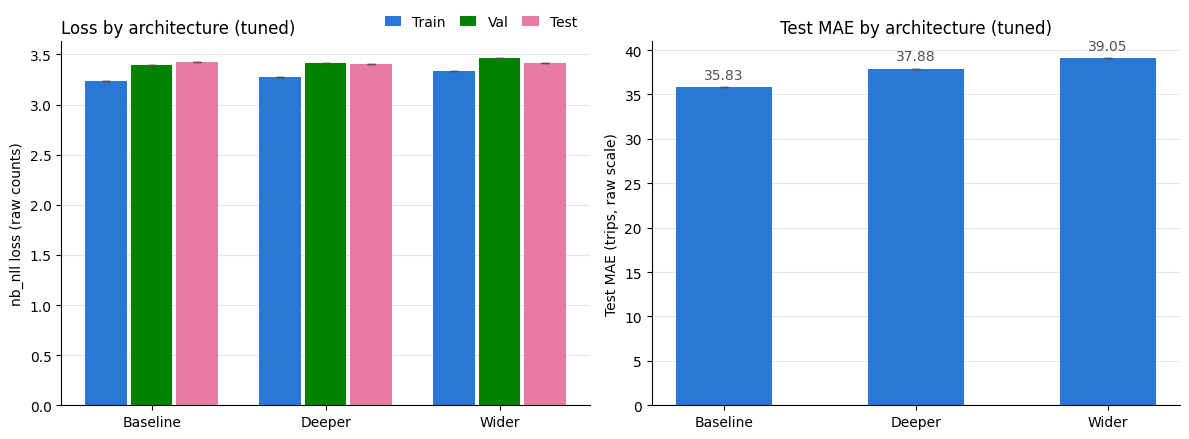

In [109]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Architecture Comparison  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# One figure over the three tuned architectures:
#   left  — train / val / test loss under the training criterion (mean ± std over seeds)
#   right — test-set MAE on the raw trip-count scale (mean ± std over seeds)
# Test loss is computed here with the same criterion as training, so the three
# bars per architecture are directly comparable (the overfitting-check printout
# in evaluate_models uses MSE on log1p scale regardless of the training loss).

import matplotlib.pyplot as plt

ARCH_RUNS = {
    "Baseline": (tuned_models,        tuned_train_losses,        tuned_val_losses),
    "Deeper":   (tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses),
    "Wider":    (tuned_wider_models,  tuned_wider_train_losses,  tuned_wider_val_losses),
}

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)
_y_target = y_test if IS_POISSON else np.log1p(y_test)   # test target on the training scale

def _test_loss_and_mae(model):
    """Per-seed test loss (training criterion) and raw-scale test MAE."""
    model.eval()
    with torch.no_grad():
        preds_raw = model(_X_test_t, _g_test_t).cpu().numpy().flatten()
    if config.LOSS == "mae":
        test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
    elif config.LOSS == "mse":
        test_loss = float(np.mean((preds_raw - _y_target) ** 2))
    elif config.LOSS == "poisson_nll":
        test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
    else:  # nb_nll — evaluate with the model's trained dispersion
        test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                      torch.as_tensor(_y_target, dtype=torch.float32),
                                      model.log_theta.detach().cpu()))
    preds = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    return test_loss, float(np.mean(np.abs(preds - y_test)))

stats = {}
for _label, (_models, _tr, _vl) in ARCH_RUNS.items():
    _per_seed = [_test_loss_and_mae(m) for m in _models]
    stats[_label] = {
        "train_loss": (np.mean(_tr), np.std(_tr)),
        "val_loss":   (np.mean(_vl), np.std(_vl)),
        "test_loss":  (np.mean([t for t, _ in _per_seed]), np.std([t for t, _ in _per_seed])),
        "mae":        (np.mean([m for _, m in _per_seed]), np.std([m for _, m in _per_seed])),
    }

summary_df = pd.DataFrame(
    {a: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in d.items()} for a, d in stats.items()}
).T
print(f"Training criterion: {config.LOSS} ({'raw counts' if IS_POISSON else 'log1p scale'}), "
      f"{len(SEEDS)} seed(s)\n")
print(summary_df.to_string())

_archs  = list(stats)
_splits = [("train_loss", "Train", "#2a78d6"),
           ("val_loss",   "Val",   "#008300"),
           ("test_loss",  "Test",  "#e87ba4")]

fig, (ax_loss, ax_mae) = plt.subplots(1, 2, figsize=(12, 4.5))
_x = np.arange(len(_archs))

for _i, (_split, _sl, _c) in enumerate(_splits):
    _means = [stats[a][_split][0] for a in _archs]
    _stds  = [stats[a][_split][1] for a in _archs]
    ax_loss.bar(_x + (_i - 1) * 0.26, _means, width=0.24, color=_c, label=_sl,
                yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
ax_loss.set_xticks(_x, _archs)
ax_loss.set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
ax_loss.set_title("Loss by architecture (tuned)", loc="left")
ax_loss.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

_means = [stats[a]["mae"][0] for a in _archs]
_stds  = [stats[a]["mae"][1] for a in _archs]
ax_mae.bar(_x, _means, width=0.5, color="#2a78d6",
           yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
for _xi, _m, _s in zip(_x, _means, _stds):
    ax_mae.annotate(f"{_m:.2f}", (_xi, _m + _s), ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="#52514e")
ax_mae.set_xticks(_x, _archs)
ax_mae.set_ylabel("Test MAE (trips, raw scale)")
ax_mae.set_title("Test MAE by architecture (tuned)")

for _ax in (ax_loss, ax_mae):
    _ax.grid(axis="y", color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

plt.tight_layout()
plt.show()


### Learning Curves

Per-epoch train / validation / test loss for each tuned architecture, all under the training criterion. The dot marks the best-validation epoch whose weights early stopping restores. Requires re-running the tuned training cells once, since `train_model` now records the history on the returned models.


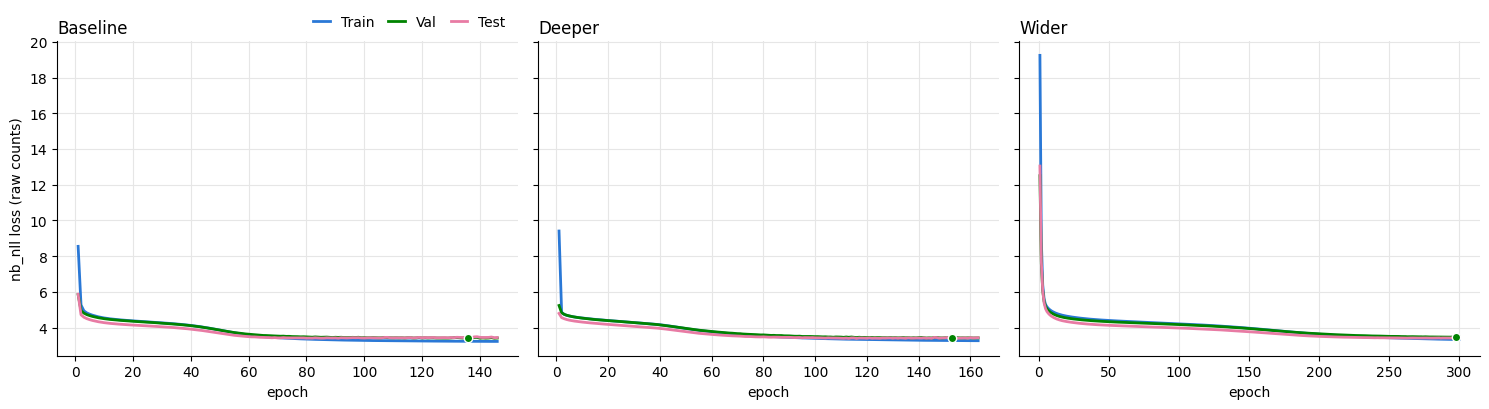

In [110]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Learning Curves          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Per-epoch train / val / test loss for the three tuned architectures.
# train_model records the history on each returned model; the tuned training
# cells pass test_data so the test curve is monitored per epoch too
# (monitoring only — it never influences training or model selection).

import matplotlib.pyplot as plt

ARCH_CURVES = {
    "Baseline": tuned_models,
    "Deeper":   tuned_deeper_models,
    "Wider":    tuned_wider_models,
}
_colors = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for _ax, (_label, _models) in zip(axes, ARCH_CURVES.items()):
    for _si, _model in enumerate(_models):
        _h = getattr(_model, "history", None)
        if _h is None:
            raise RuntimeError("model has no training history — re-run the tuned "
                               "training cells (train_model records it now)")
        _epochs = np.arange(1, len(_h["train"]) + 1)
        for _split in ("train", "val", "test"):
            if _h[_split]:
                _ax.plot(_epochs, _h[_split], color=_colors[_split], lw=2,
                         alpha=1.0 if _si == 0 else 0.4,
                         label=_split.capitalize() if _si == 0 else None)
        _best = int(np.argmin(_h["val"]))   # epoch restored by early stopping
        _ax.plot(_best + 1, _h["val"][_best], "o", ms=6, color=_colors["val"],
                 markeredgecolor="white", zorder=3)
    _ax.set_title(_label, loc="left")
    _ax.set_xlabel("epoch")
    _ax.grid(color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

axes[0].set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.show()


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

In [111]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Wilcoxon signed-rank test: is each tuned NN more accurate than the benchmarks?
# Per-row absolute errors on the held-out test set; the tuned architectures are
# seed-ensembled (mean predicted count). Every model scores the same test rows,
# so the errors are paired. One-sided H1: NN abs-error < benchmark abs-error.
# p-values are Holm-corrected across all comparisons, and because a test set this
# large makes even trivial gaps "significant", the practical effect sizes
# (median abs-error reduction, share of rows the NN wins) are shown alongside.

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks
paired over 7,227 test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05

        NN model       Benchmark  median AE (NN)  median AE (bench)  median AE reduction  NN wins %         W  p (one-sided)  n (non-tied)  p (Holm)  significant
Baseline (tuned) Historical mean           3.971              5.535                1.564      58.89 9.363e+06      9.877e-97          7227 2.963e-96         True
Baseline (tuned)           Ridge           3.971                 21                17.03       71.7 4.607e+06              0          7227         0         True
  Deeper (tuned) Historical mean           3.944              5.535                1.591      57.53 9.923e+06      3.003e-70          7227 6.006e-70         True
  Deeper (tuned)           Ridge           3.944                 21                17.06      70.69 4.908e+06              0          7227         0         True
   Wider (tuned) Historical mean           

#### Interpreting the results

**What this tests.** For each tuned architecture the per-seed models are ensembled (mean predicted count) and scored on the held-out test set. For every test row we take the *absolute error* of the NN and of a benchmark and ask — across all rows jointly — whether the NN's errors are reliably smaller. Because every model predicts the **same** rows, the errors are *paired*.

**How the Wilcoxon signed-rank test works.** Each test row contributes one difference `d = AE_NN − AE_benchmark`. Rows with `d = 0` (ties) are dropped (that is the `n (non-tied)` count); the rest are ranked by the size of `|d|`, and the ranks of the "NN better" rows are summed against the "benchmark better" rows. If the NN were no better, those two rank-sums would be about equal — a large imbalance yields a small p-value. The test uses only the **signs and ranks** of the differences, so it is robust to the zero-inflated, heavy-tailed error distribution (unlike a paired t-test). It produces **one p-value per comparison**, computed from all rows together — p-values are never averaged.

**Reading the table.** Each row is one comparison (a tuned architecture vs. one benchmark):

| Column | Meaning |
|---|---|
| `median AE (NN)` / `median AE (bench)` | Typical absolute error of each model, in trips. |
| `median AE reduction` | `median AE (bench) − median AE (NN)`. **Positive → the NN is more accurate** by that many trips at the median; negative → the benchmark is. |
| `NN wins %` | Share of test rows where the NN's error is strictly smaller. ~50 % ≈ coin flip; higher = a consistent edge. |
| `W` | The signed-rank statistic the p-value is derived from (not read directly). |
| `p (one-sided)` | Raw probability of an NN advantage this strong if the NN were truly not better. |
| `n (non-tied)` | Number of rows that actually counted (ties dropped). |
| `p (Holm)` | The p-value **after** correcting for running six comparisons — the one to judge on. |
| `significant` | `True` when `p (Holm) < 0.05`. |

**Identifying significance.** A comparison is statistically significant when **`p (Holm) < 0.05`** — exactly what the `significant` column reports. Use the Holm-corrected value, not the raw `p (one-sided)`: six comparisons run at once, and Holm correction keeps the *overall* false-positive rate at 5 %. Because the test is one-sided, a significant row means specifically that the NN is **more accurate** than the benchmark, not merely different.

**Significance is not importance.** With thousands of paired rows, almost any difference clears `p < 0.05`, so always read significance together with the effect sizes. A significant row with a `median AE reduction` of 0.05 trips and `NN wins %` of 51 % is a statistical tie in practice; a reduction of ~3 trips with 68 % wins is a real improvement. And if a row is *not* significant, check the sign of `median AE reduction`: negative (with `NN wins %` < 50 %) means the benchmark is actually the better model.